This is part 14 of a tutorial series. We recommend reading [Part 12: Introduction to DAE Solving](12.%20dae_solving_intro.ipynb) and [Part 13: MIAM Processes and Constraints](13.%20miam_processes_and_constraints.ipynb) first.

# CAM Cloud Chemistry

In this tutorial, we bring everything together into a realistic cloud chemistry simulation modeled after the [Community Atmosphere Model (CAM)](https://www.cesm.ucar.edu/models/cam) cloud chemistry module. We'll simulate:

1. **Gas-phase precursor reactions** that produce SO₂ and H₂O₂
2. **Henry's Law partitioning** of SO₂, H₂O₂, and O₃ into cloud droplets
3. **Aqueous dissociation equilibria** (SO₂ → HSO₃⁻ → SO₃²⁻, H₂O → H⁺ + OH⁻)
4. **Sulfate production** via S(IV) oxidation by H₂O₂ and O₃
5. **Conservation laws** and **charge balance**

This is a complete, self-contained example of coupled gas-aqueous chemistry using MIAM's DAE solver.

## 1. Importing Libraries

In [1]:
import math
import musica
import musica.mechanism_configuration as mc
from musica.micm import MICM, SolverType, SolverState
from musica.miam import (
    HenrysLawConstant,
    EquilibriumConstant,
    ArrheniusRateConstant,
    UniformSection,
    DissolvedReaction,
    HenryLawEquilibriumConstraint,
    DissolvedEquilibriumConstraint,
    LinearConstraint,
    LinearConstraintTerm,
    Model,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Physical Constants and Conditions

Cloud chemistry typically occurs at mid-tropospheric altitudes (~3–5 km) where temperatures are around 280 K and pressures around 700 hPa.

In [2]:
# Fundamental constants
R_GAS = 8.314                           # J/(mol·K)
T0 = 298.15                             # K (reference temperature)
M_ATM_TO_MOL_M3_PA = 1000.0 / 101325.0 # converts Henry's law from mol/(L·atm) to mol/(m³·Pa)
C_H2O_M = 55.556                        # mol/L (molar concentration of water)
C_H2O = 55556.0                         # mol/m³
MW_H2O = 0.018                          # kg/mol
RHO_H2O = 1000.0                        # kg/m³

# Atmospheric conditions
T_INIT = 280.0    # K (typical cloud temperature)
P_INIT = 70000.0  # Pa (typical cloud-level pressure, ~700 hPa)

# Initial gas-phase concentrations
# Using mol/m³ (approximately: concentration = mixing_ratio × air_density)
GAS0_SO2 = 3.01e-8     # mol/m³ (~1 ppb SO2)
GAS0_H2O2 = 3.01e-8    # mol/m³ (~1 ppb H2O2)
GAS0_O3 = 1.5e-6       # mol/m³ (~50 ppb O3)
GAS0_DMS = 3.01e-9     # mol/m³ (~100 ppt DMS)
GAS0_OH = 3.01e-13     # mol/m³ (~0.01 ppt OH, typical daytime)

# Background sulfate from previous cloud processing
SO4MM0 = 1.0  # mol/m³ in droplet

print(f"Temperature: {T_INIT} K")
print(f"Pressure: {P_INIT/100:.0f} hPa")
print(f"SO2: ~{GAS0_SO2*R_GAS*T_INIT/P_INIT*1e9:.1f} ppb")
print(f"O3:  ~{GAS0_O3*R_GAS*T_INIT/P_INIT*1e9:.0f} ppb")

Temperature: 280.0 K
Pressure: 700 hPa
SO2: ~1.0 ppb
O3:  ~50 ppb


## 3. Gas-Phase Mechanism

We include two gas-phase reactions that produce the precursors for aqueous-phase sulfate formation:

1. **DMS + OH → SO₂**: Simplified dimethyl sulfide oxidation (the dominant natural source of SO₂ over oceans)
2. **H₂O₂ emission**: A constant source representing photochemical H₂O₂ production (HO₂ + HO₂ → H₂O₂)

These gas-phase reactions are defined through `musica.mechanism_configuration` and coupled to the MIAM aqueous chemistry through the DAE solver.

In [3]:
# ── Gas-phase species ──
so2_g = mc.Species(name="SO2")
h2o2_g = mc.Species(name="H2O2")
o3_g = mc.Species(name="O3")
dms = mc.Species(name="DMS")
oh = mc.Species(name="OH")

gas = mc.Phase(name="gas", species=[so2_g, h2o2_g, o3_g, dms, oh])

# DMS + OH → SO2  (simplified — real mechanism is more complex)
# Rate constant: k = 1.1e-11 × exp(-240/T) cm³/(molec·s)
# We use a UserDefined reaction so we can set/update the rate externally
dms_oxidation = mc.UserDefined(
    name="DMS_OH_to_SO2",
    scaling_factor=1.0,
    reactants=[dms, oh],
    products=[so2_g],
    gas_phase=gas,
)

# H2O2 emission (constant source representing photochemistry)
h2o2_source = mc.Emission(
    name="H2O2_source",
    scaling_factor=1.0,
    products=[h2o2_g],
    gas_phase=gas,
)

gas_mechanism = mc.Mechanism(
    name="cloud_precursors",
    species=[so2_g, h2o2_g, o3_g, dms, oh],
    phases=[gas],
    reactions=[dms_oxidation, h2o2_source],
)

print("Gas-phase mechanism:")
for rxn in gas_mechanism.reactions:
    print(f"  [{rxn.type.name}] {rxn.to_equation()}")

Gas-phase mechanism:
  [Emission] -> H2O2
  [UserDefined] DMS + OH -> SO2


## 4. MIAM Model: Aqueous Phase

The MIAM model defines the condensed-phase species, representation, processes, and constraints. This is the heart of the CAM cloud chemistry.

### 4a. Aqueous Species

The aqueous phase contains:
- **Dissolved gases**: SO₂(aq), H₂O₂(aq), O₃(aq)
- **Dissociation products**: H⁺, OH⁻, HSO₃⁻, SO₃²⁻
- **Oxidation product**: SO₄²⁻
- **Solvent**: H₂O

In [4]:
# ── Aqueous species ──
h2o = mc.Species(name="H2O")
h2o.molecular_weight_kg_mol = MW_H2O
h2o.density_kg_m3 = RHO_H2O

so2_aq = mc.Species(name="SO2_aq")
h2o2_aq = mc.Species(name="H2O2_aq")
o3_aq = mc.Species(name="O3_aq")
hp = mc.Species(name="Hp")         # H+
ohm = mc.Species(name="OHm")       # OH-
hso3m = mc.Species(name="HSO3m")   # HSO3-
so3mm = mc.Species(name="SO3mm")   # SO3²-
so4mm = mc.Species(name="SO4mm")   # SO4²-

aq_phase = mc.Phase(
    name="AQUEOUS",
    species=[h2o, so2_aq, h2o2_aq, o3_aq, hp, ohm, hso3m, so3mm, so4mm],
)

# All species (gas + aqueous) — needed by the MIAM Model
all_species = [
    so2_g, h2o2_g, o3_g, dms, oh,
    so2_aq, h2o2_aq, o3_aq, hp, ohm, hso3m, so3mm, so4mm, h2o,
]

print(f"Total species: {len(all_species)} ({5} gas + {9} aqueous)")

Total species: 14 (5 gas + 9 aqueous)


### 4b. Cloud Droplet Representation

In [5]:
cloud = UniformSection(
    name="CLOUD",
    phase_names=["AQUEOUS"],
    min_radius=1e-6,    # 1 μm
    max_radius=1e-5,    # 10 μm
)
print(f"Cloud droplets: {cloud.min_radius*1e6:.0f}–{cloud.max_radius*1e6:.0f} μm radius")

Cloud droplets: 1–10 μm radius


### 4c. Aqueous-Phase Oxidation Reactions

The key sulfate-production reactions in cloud water:

| # | Reaction | Rate constant (M⁻¹s⁻¹ at 298 K) | Ea/R (K) |
|---|---|---|---|
| R1 | HSO₃⁻ + H₂O₂(aq) → SO₄²⁻ + H₂O + H⁺ | 7.45 × 10⁷ | 4430 |
| R2 | HSO₃⁻ + O₃(aq) → SO₄²⁻ + H⁺ | 3.75 × 10⁵ | 5530 |
| R3 | SO₃²⁻ + O₃(aq) → SO₄²⁻ | 1.59 × 10⁹ | 5280 |

R1 (the H₂O₂ pathway) dominates at low pH, while R2/R3 (the O₃ pathway) are important at higher pH where more S(IV) is in the HSO₃⁻ and SO₃²⁻ forms.

In [6]:
# R1: HSO3- + H2O2(aq) → SO4²- + H2O + H+
r1 = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["HSO3m", "H2O2_aq"],
    product_names=["SO4mm", "H2O", "Hp"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 7.45e7, c=4430.0),
)

# R2: HSO3- + O3(aq) → SO4²- + H+
r2 = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["HSO3m", "O3_aq"],
    product_names=["SO4mm", "Hp"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 3.75e5, c=5530.0),
)

# R3: SO3²- + O3(aq) → SO4²-
r3 = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["SO3mm", "O3_aq"],
    product_names=["SO4mm"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 1.59e9, c=5280.0),
)

print("Aqueous oxidation reactions defined:")
print("  R1: HSO3- + H2O2(aq) → SO4²- + H2O + H+")
print("  R2: HSO3- + O3(aq) → SO4²- + H+")
print("  R3: SO3²- + O3(aq) → SO4²-")

Aqueous oxidation reactions defined:
  R1: HSO3- + H2O2(aq) → SO4²- + H2O + H+
  R2: HSO3- + O3(aq) → SO4²- + H+
  R3: SO3²- + O3(aq) → SO4²-


### 4d. Constraints

The constraint system couples the gas and aqueous phases and enforces thermodynamic consistency. We use 10 constraints:

| Type | Equation | Algebraic species |
|---|---|---|
| Henry's Law | SO₂(aq) = α × SO₂(g) | SO₂(aq) |
| Henry's Law | H₂O₂(aq) = α × H₂O₂(g) | H₂O₂(aq) |
| Henry's Law | O₃(aq) = α × O₃(g) | O₃(aq) |
| Dissociation | Kw: H₂O ⇌ H⁺ + OH⁻ | OH⁻ |
| Dissociation | Ka1: SO₂(aq) ⇌ HSO₃⁻ + H⁺ | HSO₃⁻ |
| Dissociation | Ka2: HSO₃⁻ ⇌ SO₃²⁻ + H⁺ | SO₃²⁻ |
| Mass conservation | Total S = SO₂(g) + SO₂(aq) + HSO₃⁻ + SO₃²⁻ + SO₄²⁻ | SO₂(g) |
| Mass conservation | Total H₂O₂ = H₂O₂(g) + H₂O₂(aq) | H₂O₂(g) |
| Mass conservation | Total O₃ = O₃(g) + O₃(aq) | O₃(g) |
| Charge balance | H⁺ = OH⁻ + HSO₃⁻ + 2SO₃²⁻ + 2SO₄²⁻ | H⁺ |

In [7]:
constraints = []

# ── Henry's Law equilibria ──
# K_H values from Sander (2015), converted to mol/(m³·Pa)
henry_law_species = [
    ("SO2",  "SO2_aq",  1.23,    3120.0),   # K_H = 1.23 mol/(L·atm)
    ("H2O2", "H2O2_aq", 7.4e4,   6621.0),   # K_H = 7.4e4 mol/(L·atm)
    ("O3",   "O3_aq",   1.15e-2, 2560.0),   # K_H = 1.15e-2 mol/(L·atm)
]

for gas_name, aq_name, hlc_ref_lit, c in henry_law_species:
    constraints.append(HenryLawEquilibriumConstraint(
        gas_species_name=gas_name,
        condensed_species_name=aq_name,
        solvent_name="H2O",
        condensed_phase_name="AQUEOUS",
        henrys_law_constant=HenrysLawConstant(
            hlc_ref=hlc_ref_lit * M_ATM_TO_MOL_M3_PA,  # convert to mol/(m³·Pa)
            c=c,
        ),
        mw_solvent=MW_H2O,
        rho_solvent=RHO_H2O,
    ))

# ── Dissociation equilibria ──
# Kw: H2O ⇌ H+ + OH-     (Kw = 1e-14 M²)
constraints.append(DissolvedEquilibriumConstraint(
    phase_name="AQUEOUS",
    reactant_names=["H2O"],
    product_names=["Hp", "OHm"],
    algebraic_species_name="OHm",
    solvent_name="H2O",
    equilibrium_constant=EquilibriumConstant(
        a=1e-14 / (C_H2O_M * C_H2O_M), c=0.0),
))

# Ka1: SO2(aq) ⇌ HSO3- + H+   (Ka1 = 1.7e-2 M)
constraints.append(DissolvedEquilibriumConstraint(
    phase_name="AQUEOUS",
    reactant_names=["SO2_aq"],
    product_names=["HSO3m", "Hp"],
    algebraic_species_name="HSO3m",
    solvent_name="H2O",
    equilibrium_constant=EquilibriumConstant(a=1.7e-2 / C_H2O_M, c=2090.0),
))

# Ka2: HSO3- ⇌ SO3²- + H+   (Ka2 = 6.0e-8 M)
constraints.append(DissolvedEquilibriumConstraint(
    phase_name="AQUEOUS",
    reactant_names=["HSO3m"],
    product_names=["SO3mm", "Hp"],
    algebraic_species_name="SO3mm",
    solvent_name="H2O",
    equilibrium_constant=EquilibriumConstant(a=6.0e-8 / C_H2O_M, c=1120.0),
))

# ── Mass conservation ──
# Total S includes SO4 (kinetics transfer S between S(IV) and S(VI) pools)
total_S = GAS0_SO2 + SO4MM0
constraints.append(LinearConstraint(
    algebraic_phase_name="gas",
    algebraic_species_name="SO2",
    terms=[
        LinearConstraintTerm("gas", "SO2", 1.0),
        LinearConstraintTerm("AQUEOUS", "SO2_aq", 1.0),
        LinearConstraintTerm("AQUEOUS", "HSO3m", 1.0),
        LinearConstraintTerm("AQUEOUS", "SO3mm", 1.0),
        LinearConstraintTerm("AQUEOUS", "SO4mm", 1.0),
    ],
    constant=total_S,
))

# Total H2O2
constraints.append(LinearConstraint(
    algebraic_phase_name="gas",
    algebraic_species_name="H2O2",
    terms=[
        LinearConstraintTerm("gas", "H2O2", 1.0),
        LinearConstraintTerm("AQUEOUS", "H2O2_aq", 1.0),
    ],
    constant=GAS0_H2O2,
))

# Total O3
constraints.append(LinearConstraint(
    algebraic_phase_name="gas",
    algebraic_species_name="O3",
    terms=[
        LinearConstraintTerm("gas", "O3", 1.0),
        LinearConstraintTerm("AQUEOUS", "O3_aq", 1.0),
    ],
    constant=GAS0_O3,
))

# ── Charge balance ──
# H+ = OH- + HSO3- + 2×SO3²- + 2×SO4²-
constraints.append(LinearConstraint(
    algebraic_phase_name="AQUEOUS",
    algebraic_species_name="Hp",
    terms=[
        LinearConstraintTerm("AQUEOUS", "Hp", 1.0),
        LinearConstraintTerm("AQUEOUS", "OHm", -1.0),
        LinearConstraintTerm("AQUEOUS", "HSO3m", -1.0),
        LinearConstraintTerm("AQUEOUS", "SO3mm", -2.0),
        LinearConstraintTerm("AQUEOUS", "SO4mm", -2.0),
    ],
    constant=0.0,
))

print(f"Constraints defined: {len(constraints)} total")
print(f"  3 Henry's Law, 3 dissociation, 3 mass conservation, 1 charge balance")

Constraints defined: 10 total
  3 Henry's Law, 3 dissociation, 3 mass conservation, 1 charge balance


### 4e. Assembling the MIAM Model

In [8]:
miam_model = Model(
    name="cam_cloud_chemistry",
    species=all_species,
    condensed_phases=[aq_phase],
    representations=[cloud],
    processes=[r1, r2, r3],
    constraints=constraints,
)

print("MIAM model assembled:")
print(f"  Species: {len(all_species)}")
print(f"  Processes: {len(miam_model.processes)}")
print(f"  Constraints: {len(miam_model.constraints)}")

MIAM model assembled:
  Species: 14
  Processes: 3
  Constraints: 10


## 5. Creating the Coupled Solver

We create a single MICM solver that integrates both the gas-phase reactions (from the mechanism) and the aqueous chemistry (from the MIAM model) as a unified DAE system.

In [9]:
micm = MICM(
    mechanism=gas_mechanism,
    solver_type=SolverType.rosenbrock_dae4_standard_order,
    external_models=[miam_model],
)

state = micm.create_state()
miam_model.set_default_parameters(state)
state.set_conditions(temperatures=T_INIT, pressures=P_INIT)

print(f"Solver type: {micm.solver_type().name}")
print(f"State created successfully.")

Solver type: rosenbrock_dae4_standard_order
State created successfully.


## 6. Initial Conditions

The MICM DAE solver automatically runs a Newton iteration on the algebraic variables at the start of each `solve()` call, projecting them onto the constraint manifold. This means we only need to provide reasonable guesses for the initial concentrations — the solver will correct them.

In [10]:
# Simple initial guesses — the solver's constraint initialization will
# adjust all algebraic variables (aqueous species, H+, etc.) to satisfy
# the constraint equations before time-stepping begins.
#
# NOTE: If constraint initialization fails (SolverState.ConstraintInitializationFailed),
# you can pre-compute more accurate initial conditions prior to calling the solve function
ics = {
    "SO2": GAS0_SO2,
    "H2O2": GAS0_H2O2,
    "O3": GAS0_O3,
    "DMS": GAS0_DMS,
    "OH": GAS0_OH,
    "CLOUD.AQUEOUS.H2O": C_H2O,
    "CLOUD.AQUEOUS.SO2_aq": 1e-10,
    "CLOUD.AQUEOUS.H2O2_aq": 1e-10,
    "CLOUD.AQUEOUS.O3_aq": 1e-10,
    "CLOUD.AQUEOUS.Hp": 2.0 * SO4MM0,  # rough guess dominated by background sulfate
    "CLOUD.AQUEOUS.OHm": 1e-10,
    "CLOUD.AQUEOUS.HSO3m": 1e-10,
    "CLOUD.AQUEOUS.SO3mm": 1e-10,
    "CLOUD.AQUEOUS.SO4mm": SO4MM0,
}

state.set_concentrations(ics)

print("Initial conditions (before constraint initialization):")
print(f"  SO2(g):    {ics['SO2']:.3e} mol/m³")
print(f"  SO4²-:     {ics['CLOUD.AQUEOUS.SO4mm']:.3e} mol/m³")
print(f"  H+(guess): {ics['CLOUD.AQUEOUS.Hp']:.3e} mol/m³")

Initial conditions (before constraint initialization):
  SO2(g):    3.010e-08 mol/m³
  SO4²-:     1.000e+00 mol/m³
  H+(guess): 2.000e+00 mol/m³


## 7. Setting Gas-Phase Rate Parameters

The `UserDefined` and `Emission` reactions require us to set their rates externally. We'll keep the DMS+OH rate constant and the H₂O₂ emission rate constant throughout the simulation.

In [11]:
# DMS + OH rate constant: k = 1.1e-11 × exp(-240/T) cm³/(molec·s)
# Convert to mol/m³ basis (MICM convention)
# The UserDefined rate is applied as: d[DMS]/dt = -rate × [DMS] × [OH]
k_dms = 1.1e-11 * math.exp(-240.0 / T_INIT)  # cm³/(molec·s)
# Convert: 1 cm³/molec/s = 6.022e23 × 1e-6 m³/(mol·s)
k_dms_musica = k_dms * 6.022e23 * 1e-6  # m³/(mol·s)

# H2O2 emission: modest source replacing photochemical production
# Emission rate in mol/(m³·s)
emis_h2o2 = 1e-12  # mol/(m³·s)

state.set_user_defined_rate_parameters({
    "USER.DMS_OH_to_SO2": k_dms_musica,
    "EMIS.H2O2_source": emis_h2o2,
})

print(f"DMS+OH rate constant: {k_dms_musica:.2e} m³/(mol·s)")
print(f"H2O2 emission rate:   {emis_h2o2:.2e} mol/(m³·s)")

DMS+OH rate constant: 2.81e+06 m³/(mol·s)
H2O2 emission rate:   1.00e-12 mol/(m³·s)


## 8. Running the Simulation

We'll simulate 30 minutes (1800 seconds) of cloud processing with 10-second output steps. The MICM Rosenbrock solver handles adaptive sub-stepping internally — it starts each call at `1e-6 × dt` and grows the internal step as the error controller allows — so no manual timestep ramp-up is needed.

In [12]:
# ── Integration loop ──
target_time = 1800.0  # 30 minutes
output_interval = 10.0  # Record every 10 s

# Collect results
times = [0.0]
results = [state.get_concentrations()]

total_time = 0.0
next_output = output_interval

while total_time < target_time - 1e-10:
    dt = min(output_interval, target_time - total_time)
    result = micm.solve(state, time_step=dt)
    assert result.state == SolverState.Converged, \
        f"Solver failed at t={total_time:.4f}s (dt={dt:.4e})"
    total_time += dt

    times.append(total_time)
    results.append(state.get_concentrations())

print(f"Simulation complete: {total_time:.0f} s ({total_time/60:.0f} minutes)")
print(f"Output timesteps: {len(times)}")

Simulation complete: 1800 s (30 minutes)
Output timesteps: 181


## 9. Results: Time Series

Let's visualize the key quantities: gas-phase SO₂ depletion, sulfate production, and pH evolution.

In [13]:
# Extract time series for key species
# Skip t=0 (pre-constraint-initialization values are not physically consistent)
def extract_series(name):
    return np.array([r[name][0] for r in results[1:]])

t = np.array(times[1:])
so2_g_ts = extract_series("SO2")
so4_ts = extract_series("CLOUD.AQUEOUS.SO4mm")
hp_ts = extract_series("CLOUD.AQUEOUS.Hp")
h2o2_g_ts = extract_series("H2O2")
so2_aq_ts = extract_series("CLOUD.AQUEOUS.SO2_aq")
hso3_ts = extract_series("CLOUD.AQUEOUS.HSO3m")
so3_ts = extract_series("CLOUD.AQUEOUS.SO3mm")
dms_ts = extract_series("DMS")

# Convert H+ to pH (H+ is in mol/m³; divide by 1000 to get mol/L)
pH_ts = -np.log10(hp_ts / 1000.0)

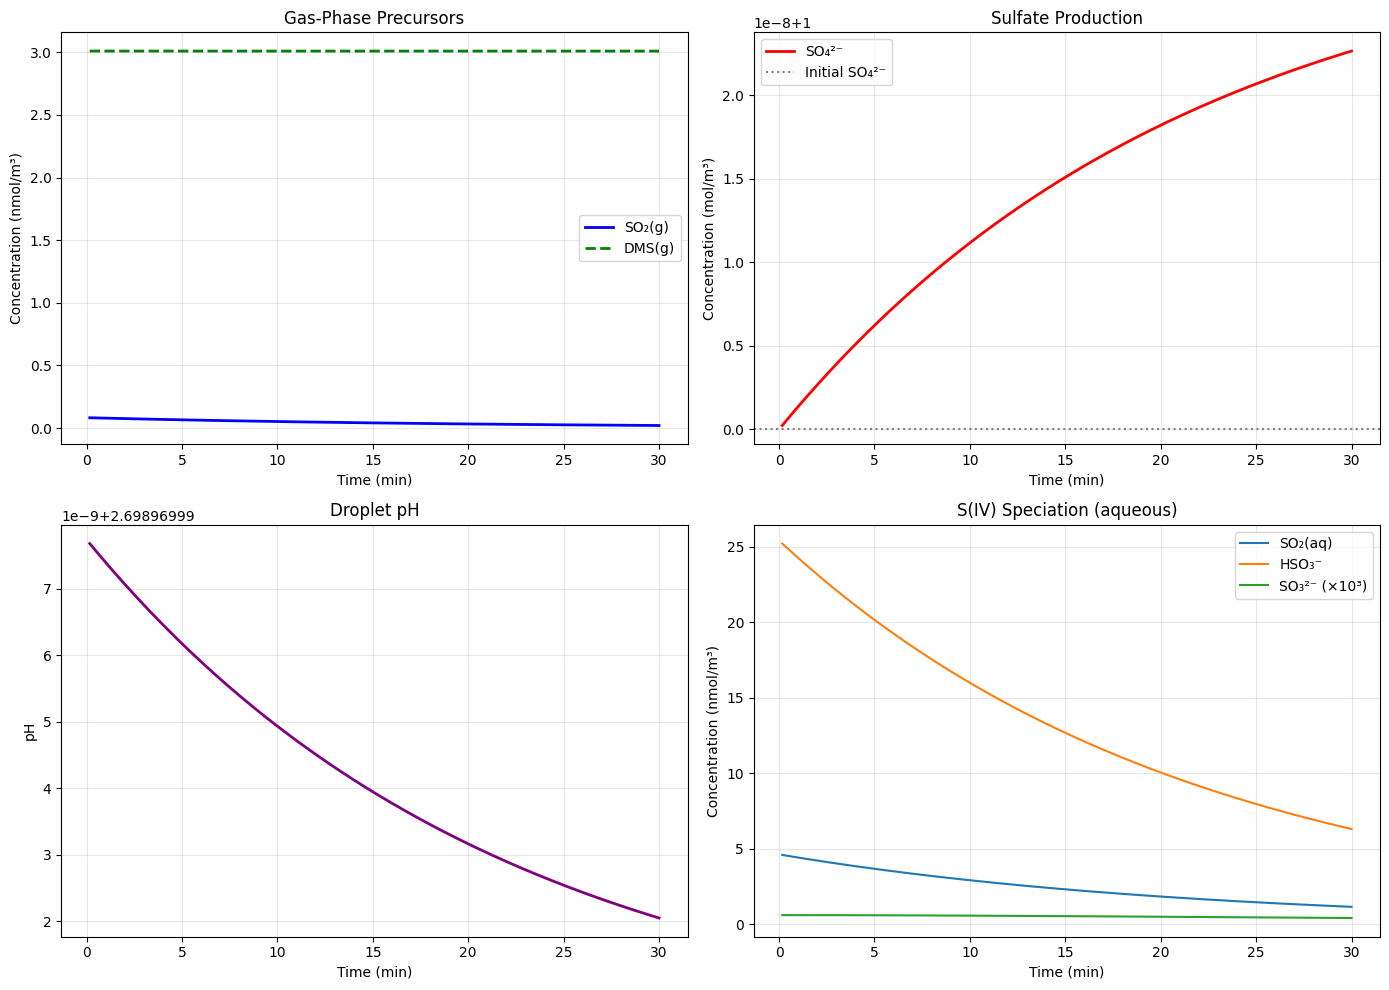

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Gas-phase SO2 and DMS
ax = axes[0, 0]
ax.plot(t/60, so2_g_ts * 1e9, 'b-', linewidth=2, label='SO₂(g)')
ax.plot(t/60, dms_ts * 1e9, 'g--', linewidth=2, label='DMS(g)')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Concentration (nmol/m³)')
ax.set_title('Gas-Phase Precursors')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Sulfate production
ax = axes[0, 1]
ax.plot(t/60, so4_ts, 'r-', linewidth=2, label='SO₄²⁻')
ax.axhline(y=SO4MM0, color='gray', linestyle=':', label='Initial SO₄²⁻')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Concentration (mol/m³)')
ax.set_title('Sulfate Production')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: pH evolution
ax = axes[1, 0]
ax.plot(t/60, pH_ts, 'purple', linewidth=2)
ax.set_xlabel('Time (min)')
ax.set_ylabel('pH')
ax.set_title('Droplet pH')
ax.grid(True, alpha=0.3)

# Panel 4: S(IV) speciation in aqueous phase
ax = axes[1, 1]
ax.plot(t/60, so2_aq_ts * 1e9, label='SO₂(aq)')
ax.plot(t/60, hso3_ts * 1e9, label='HSO₃⁻')
ax.plot(t/60, so3_ts * 1e12, label='SO₃²⁻ (×10³)')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Concentration (nmol/m³)')
ax.set_title('S(IV) Speciation (aqueous)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Validation: Conservation Laws and Equilibria

Let's verify that the solver maintains the physical constraints throughout the simulation.

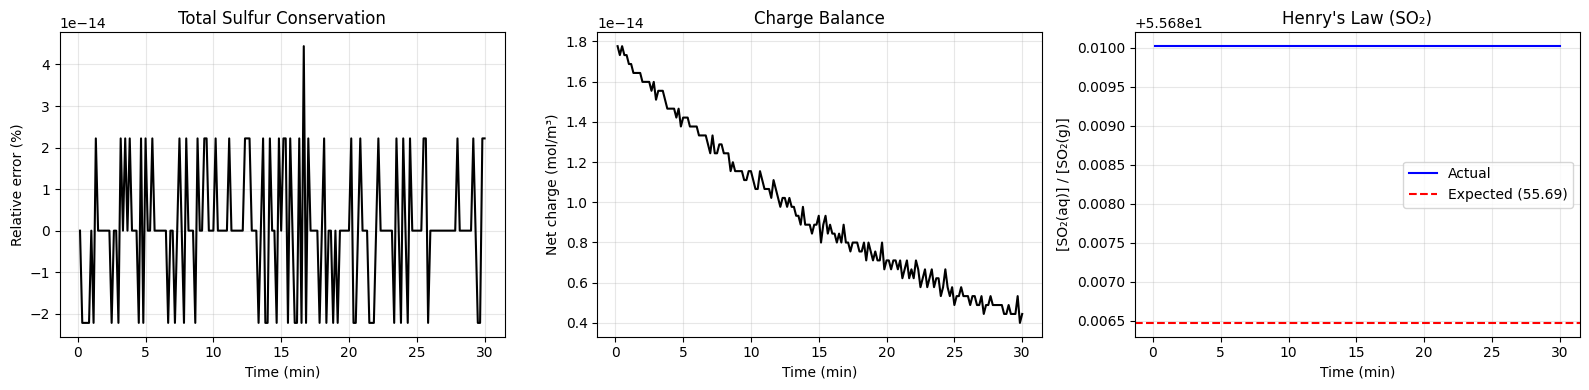

Max sulfur conservation error: 4.44e-16
Max charge imbalance:          1.78e-14 mol/m³
Max Henry's Law error:         6.36e-05


In [15]:
# ── Total sulfur conservation ──
total_S_ts = so2_g_ts + so2_aq_ts + hso3_ts + so3_ts + so4_ts

# ── Charge balance ──
ohm_ts = extract_series("CLOUD.AQUEOUS.OHm")
charge_ts = hp_ts - ohm_ts - hso3_ts - 2*so3_ts - 2*so4_ts

# ── Henry's Law ratio for SO2 ──
hlc_T = (1.23 * M_ATM_TO_MOL_M3_PA) * math.exp(3120.0 * (1.0/T_INIT - 1.0/T0))
alpha_expected = hlc_T * R_GAS * T_INIT
alpha_actual = so2_aq_ts / np.where(so2_g_ts > 0, so2_g_ts, 1e-30)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Mass conservation
ax = axes[0]
ax.plot(t/60, (total_S_ts / total_S - 1) * 100, 'k-', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Relative error (%)')
ax.set_title('Total Sulfur Conservation')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3,3))

# Charge balance
ax = axes[1]
ax.plot(t/60, charge_ts, 'k-', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Net charge (mol/m³)')
ax.set_title('Charge Balance')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3,3))

# Henry's Law ratio
ax = axes[2]
ax.plot(t/60, alpha_actual, 'b-', linewidth=1.5, label='Actual')
ax.axhline(y=alpha_expected, color='red', linestyle='--', label=f'Expected ({alpha_expected:.2f})')
ax.set_xlabel('Time (min)')
ax.set_ylabel('[SO₂(aq)] / [SO₂(g)]')
ax.set_title("Henry's Law (SO₂)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"Max sulfur conservation error: {abs(total_S_ts/total_S - 1).max():.2e}")
print(f"Max charge imbalance:          {abs(charge_ts).max():.2e} mol/m³")
print(f"Max Henry's Law error:         {abs(alpha_actual/alpha_expected - 1).max():.2e}")

## 11. Discussion: The Self-Limiting Mechanism

Notice a key feature of the results:

1. **SO₂ depletes rapidly** at first, as the oxidation reactions consume S(IV)
2. **SO₄²⁻ increases**, producing H⁺ (acid)
3. **pH drops** as acid accumulates
4. **Lower pH shifts the S(IV) speciation** toward SO₂(aq) and away from HSO₃⁻/SO₃²⁻
5. Since the oxidation reactions consume HSO₃⁻ and SO₃²⁻ (not SO₂(aq) directly), **the oxidation rate decreases**

This is the classical **self-limiting mechanism** of cloud sulfate production: the acid produced by sulfate formation suppresses further sulfate production. This feedback is correctly captured by the DAE solver because the pH (via the charge balance constraint) is coupled to the kinetics at every solver stage.

With process splitting, this feedback would be delayed by one timestep — leading to overestimation of sulfate production.

## 12. Extensions

This tutorial demonstrated the core CAM cloud chemistry system. Here are some directions you can explore:

- **Multiple grid cells**: Create a state with `num_grid_cells > 1` and set different temperatures, pressures, and initial concentrations for each cell. This is how you'd represent a vertical cloud column (see [Tutorial 1](1.%20multiple_grid_cells.ipynb)).

- **Varying liquid water content**: Change the cloud droplet representation parameters (`min_radius`, `max_radius`) or switch to `SingleMomentMode` to represent different cloud types (thin cirrus vs. thick cumulus).

- **Couple with TUV-x for photolysis**: Replace the constant H₂O₂ emission with photochemical production driven by TUV-x photolysis rates (see [Tutorials 8–11](8.%20tuv-x_standard_configurations.ipynb) for the coupling pattern).

- **Add more oxidants**: Include iron-catalyzed oxidation (Fe(III) + S(IV) → S(VI)) or TMI chemistry for a more complete sulfur cycle.

- **Export your mechanism**: Use `gas_mechanism.export("my_config.json")` to save your gas-phase mechanism as a configuration file you can use in CAM-SIMA or other MUSICA-based models.